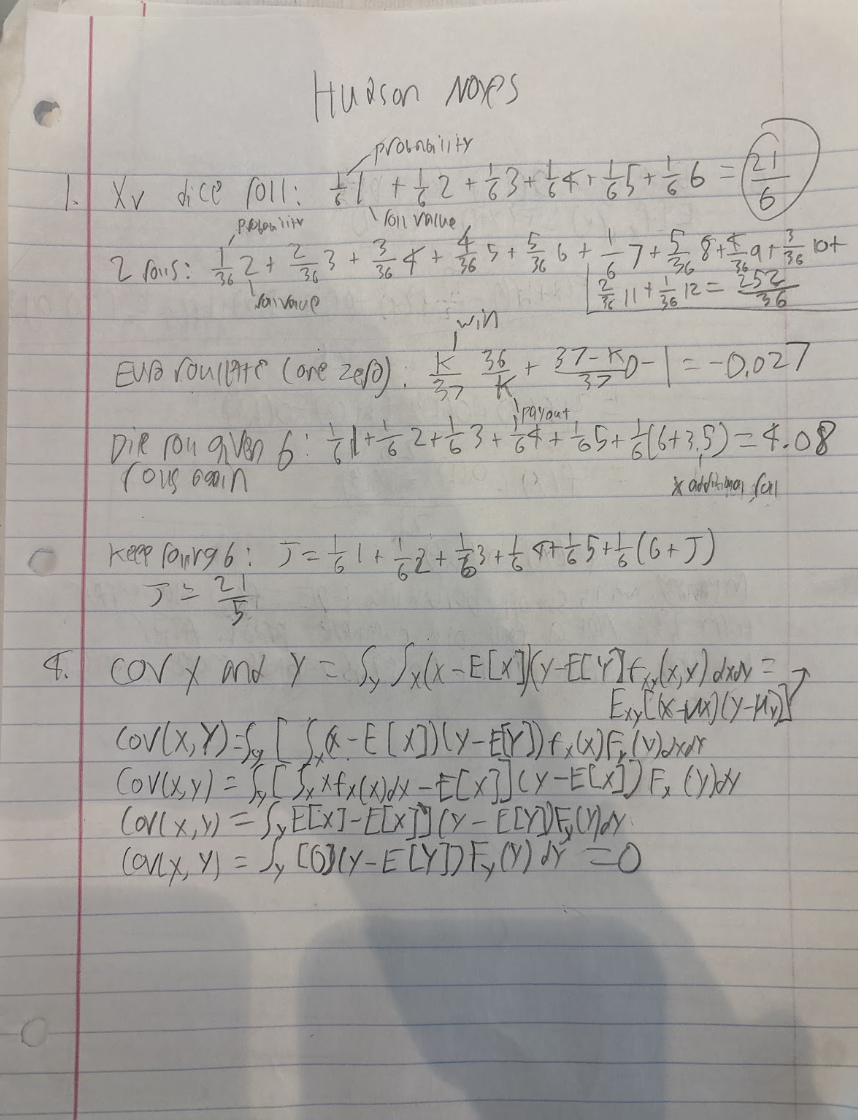

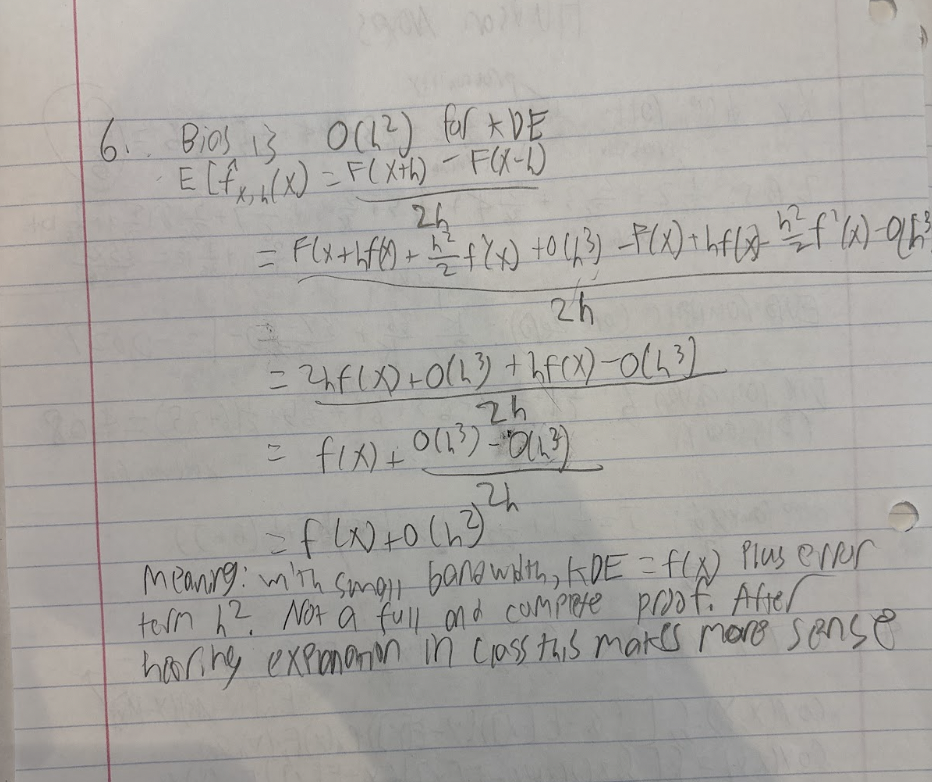

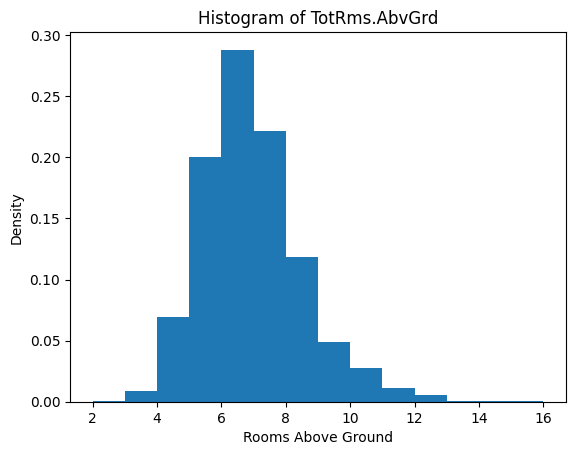

MLE λ: 6.443003412969284


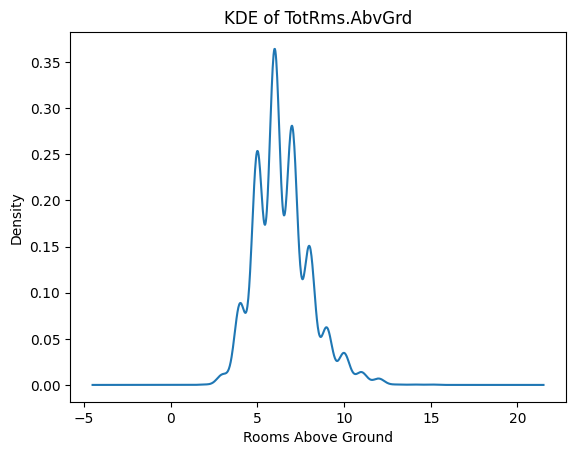

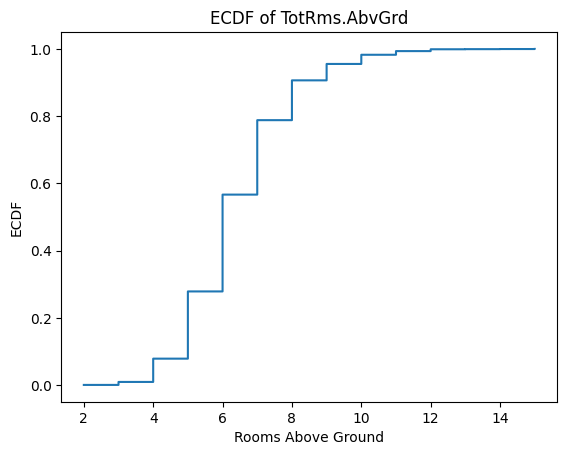

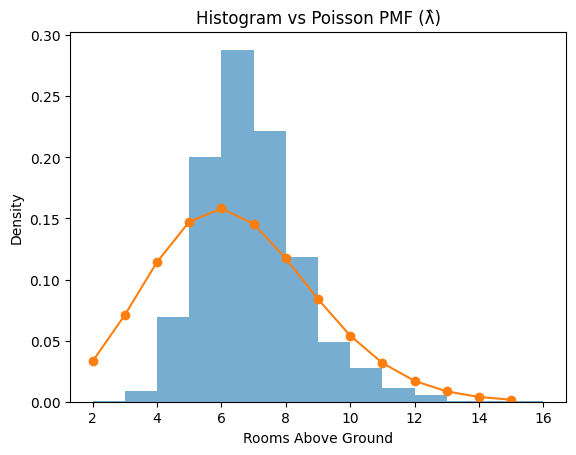

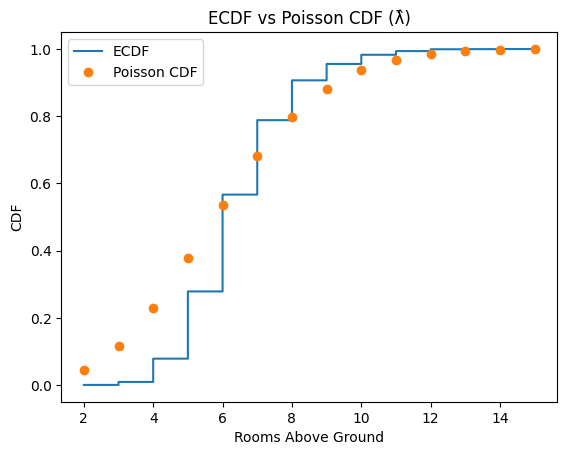

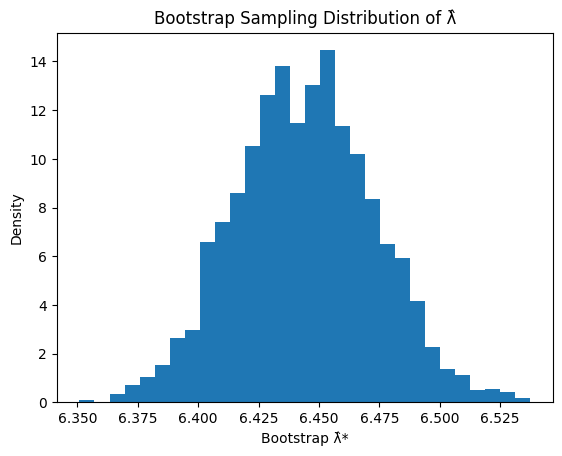

Bootstrap mean: 6.444166211604095
95% CI: (np.float64(6.390102389078498), np.float64(6.500349829351536))


In [1]:
#11
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Load data
df = pd.read_csv("ames_prices.csv")

# Pick column
if "TotRms.AbvGrd" in df.columns:
    col = "TotRms.AbvGrd"
elif "TotRmsAbvGrd" in df.columns:
    col = "TotRmsAbvGrd"
else:
    col = df.columns[0]

# Prepare values
rooms = df[col].dropna().astype(int)

# Histogram
plt.figure()
plt.hist(rooms, bins=range(rooms.min(), rooms.max() + 2), density=True)
plt.xlabel("Rooms Above Ground")
plt.ylabel("Density")
plt.title("Histogram of TotRms.AbvGrd")
plt.show()

# Poisson MLE (mean)
lambda_hat = rooms.mean()
print("MLE λ:", lambda_hat)

# KDE
plt.figure()
rooms.plot(kind="kde")
plt.xlabel("Rooms Above Ground")
plt.title("KDE of TotRms.AbvGrd")
plt.show()

# ECDF
rooms_sorted = np.sort(rooms)
ecdf = np.arange(1, len(rooms_sorted) + 1) / len(rooms_sorted)

plt.figure()
plt.step(rooms_sorted, ecdf, where="post")
plt.xlabel("Rooms Above Ground")
plt.ylabel("ECDF")
plt.title("ECDF of TotRms.AbvGrd")
plt.show()

# Poisson PMF
k_vals = np.arange(rooms.min(), rooms.max() + 1)
pmf_vals = poisson.pmf(k_vals, lambda_hat)

plt.figure()
plt.hist(rooms, bins=range(rooms.min(), rooms.max() + 2), density=True, alpha=0.6)
plt.plot(k_vals, pmf_vals, marker="o")
plt.xlabel("Rooms Above Ground")
plt.ylabel("Density")
plt.title("Histogram vs Poisson PMF (λ̂)")
plt.show()

# Poisson CDF vs ECDF
cdf_vals = poisson.cdf(k_vals, lambda_hat)

plt.figure()
plt.step(rooms_sorted, ecdf, where="post", label="ECDF")
plt.plot(k_vals, cdf_vals, marker="o", linestyle="none", label="Poisson CDF")
plt.xlabel("Rooms Above Ground")
plt.ylabel("CDF")
plt.title("ECDF vs Poisson CDF (λ̂)")
plt.legend()
plt.show()

# Bootstrap distribution of lambda_hat
B = 2000
n = len(rooms)
boot_means = np.zeros(B)

for b in range(B):
    sample = np.random.choice(rooms, size=n, replace=True)
    boot_means[b] = sample.mean()

plt.figure()
plt.hist(boot_means, bins=30, density=True)
plt.xlabel("Bootstrap λ̂*")
plt.ylabel("Density")
plt.title("Bootstrap Sampling Distribution of λ̂")
plt.show()

# Bootstrap CI
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print("Bootstrap mean:", boot_means.mean())
print("95% CI:", (ci_low, ci_high))

Likelihood function for both 11 and 12

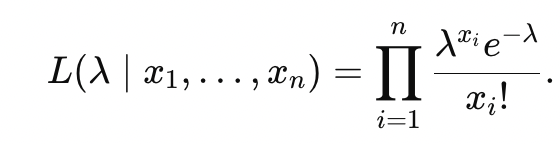

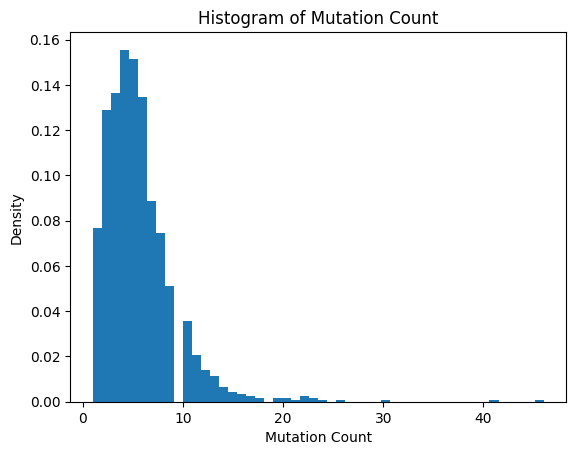

MLE λ: 5.494415487714073


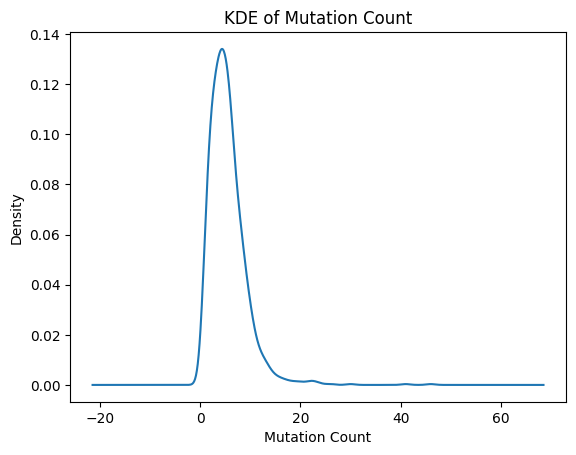

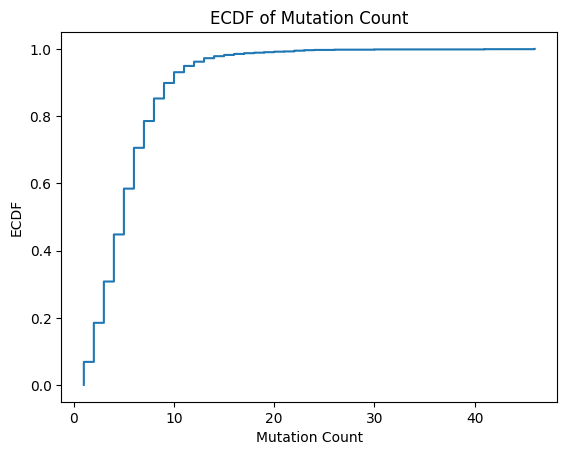

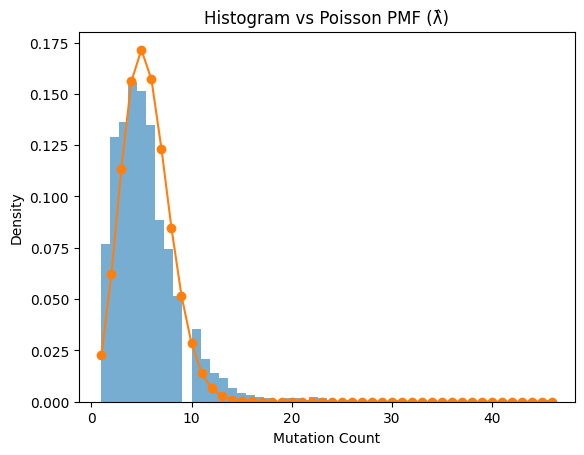

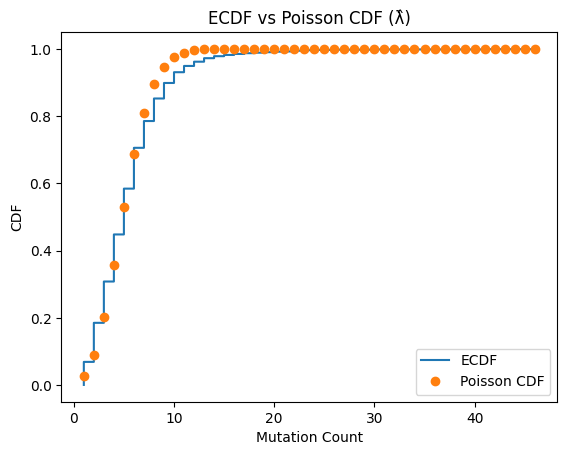

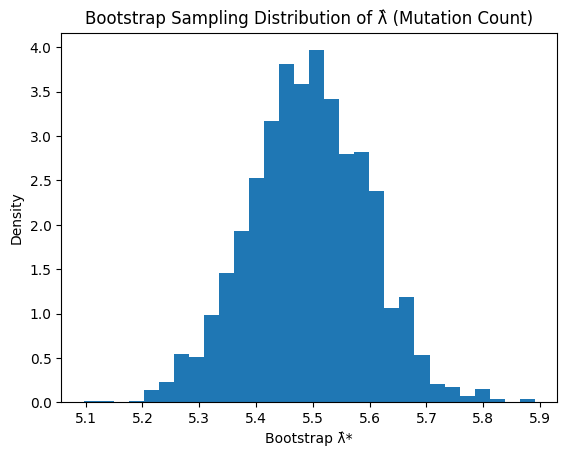

Bootstrap mean: 5.493056589724498
95% CI: (np.float64(5.276247207743857), np.float64(5.6895197319434105))


In [2]:
#12
# Load METABRIC data
df = pd.read_csv("metabric.csv")

# Use Mutation Count column
mut = df["Mutation Count"].dropna()

# Histogram with about 50 bins
plt.figure()
plt.hist(mut, bins=50, density=True)
plt.xlabel("Mutation Count")
plt.ylabel("Density")
plt.title("Histogram of Mutation Count")
plt.show()

# Poisson MLE (mean)
lambda_hat = mut.mean()
print("MLE λ:", lambda_hat)

# KDE
plt.figure()
mut.plot(kind="kde")
plt.xlabel("Mutation Count")
plt.title("KDE of Mutation Count")
plt.show()

# ECDF
mut_sorted = np.sort(mut)
ecdf = np.arange(1, len(mut_sorted) + 1) / len(mut_sorted)

plt.figure()
plt.step(mut_sorted, ecdf, where="post")
plt.xlabel("Mutation Count")
plt.ylabel("ECDF")
plt.title("ECDF of Mutation Count")
plt.show()

# Poisson PMF on observed range
k_vals = np.arange(mut.min(), mut.max() + 1)
pmf_vals = poisson.pmf(k_vals, lambda_hat)

plt.figure()
plt.hist(mut, bins=50, density=True, alpha=0.6)
plt.plot(k_vals, pmf_vals, marker="o")
plt.xlabel("Mutation Count")
plt.ylabel("Density")
plt.title("Histogram vs Poisson PMF (λ̂)")
plt.show()

# Poisson CDF vs ECDF
cdf_vals = poisson.cdf(k_vals, lambda_hat)

plt.figure()
plt.step(mut_sorted, ecdf, where="post", label="ECDF")
plt.plot(k_vals, cdf_vals, marker="o", linestyle="none", label="Poisson CDF")
plt.xlabel("Mutation Count")
plt.ylabel("CDF")
plt.title("ECDF vs Poisson CDF (λ̂)")
plt.legend()
plt.show()

# Bootstrap sampling distribution of lambda_hat
B = 2000
n = len(mut)
boot_means = np.zeros(B)

for b in range(B):
    sample = np.random.choice(mut, size=n, replace=True)
    boot_means[b] = sample.mean()

plt.figure()
plt.hist(boot_means, bins=30, density=True)
plt.xlabel("Bootstrap λ̂*")
plt.ylabel("Density")
plt.title("Bootstrap Sampling Distribution of λ̂ (Mutation Count)")
plt.show()

# Bootstrap summary
boot_mean = boot_means.mean()
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print("Bootstrap mean:", boot_mean)
print("95% CI:", (ci_low, ci_high))
